In [ ]:
import pandas as pd

import numpy as np
from copy import deepcopy

# df = pd.read_csv(r'D:\github\Python_codes\temperature_data\wr323268.csv', sep=';')
data = pd.read_excel(r'D:\github\Python_codes\temperature_data\olegy хелп.xlsx')
# df_copy = deepcopy(df)

data.head()

NameError: name 'df' is not defined

In [36]:
import pandas as pd

# Чтение файла Excel (если он корректно читается без указания кодировки)
excel_df = pd.read_excel("temperature_data\\olegy хелп.xlsx")

# Чтение CSV файла с указанием кодировки 'cp1251'
csv_df = pd.read_csv("temperature_data\\statlist323268.csv", encoding='cp1251', sep=';')

# Предположим, что искомые индексы находятся в первом столбце каждого файла.
index_col_excel = excel_df.columns[0]
index_col_csv = csv_df.columns[0]

# Извлечение уникальных значений индексов без пропусков
indices_excel = set(excel_df[index_col_excel].dropna().unique())
indices_csv = set(csv_df[index_col_csv].dropna().unique())

# Нахождение общих индексов
common_indices = sorted(indices_excel.intersection(indices_csv))

# Формирование DataFrame для сохранения результата
result_df = pd.DataFrame(common_indices, columns=["CommonIndex"])

# Запись результата в CSV-файл
result_df.to_csv("common_indices.csv", index=False)

print("CSV файл 'common_indices.csv' успешно создан.")


CSV файл 'common_indices.csv' успешно создан.


In [7]:
data =pd.read_csv(r'temperature_data\wr323268_fixed.csv', sep=';')
data.head()
data_copy = data.head(1000)
data_copy.to_csv(r'temperature_data\wr323268_copy.csv', sep=';')
data_copy

<ipython-input-7-6066811967f3>:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data =pd.read_csv(r'temperature_data\wr323268_fixed.csv', sep=';')


,Col1,Col2,Col3,Col4,Col5
0,20046.0,1958.0,1.0,1.0,-34.0
1,20046.0,1958.0,1.0,2.0,NaN
2,20046.0,1958.0,1.0,3.0,NaN
3,20046.0,1958.0,1.0,4.0,-37.6
4,20046.0,1958.0,1.0,5.0,-34.8
...,...,...,...,...,...
995,20046.0,1960.0,9.0,22.0,NaN
996,20046.0,1960.0,9.0,23.0,NaN
997,20046.0,1960.0,9.0,24.0,NaN
998,20046.0,1960.0,9.0,25.0,NaN


In [1]:
import csv
import pandas as pd

input_file = "temperature_data\wr323268.csv"
output_file = "wr323268_fixed.csv"
encoding = "cp1251"   # при необходимости смените кодировку
delimiter = ";"       # разделитель CSV-файла
expected_cols = 5     # сколько столбцов должно быть в итоге

fixed_rows = []

with open(input_file, "r", encoding=encoding, newline="") as f:
    reader = csv.reader(f, delimiter=delimiter)
    for row in reader:
        # Если в строке больше нужного количества столбцов,
        # объединяем всё, что "выползло" за границу, в последний столбец.
        while len(row) < expected_cols:
            row.append("NaN")
            
        if len(row) > expected_cols:
            row = row[:expected_cols-1] + [delimiter.join(row[expected_cols-1:])]

        # Если в строке столбцов меньше, чем нужно,
        # заполняем отсутствующие столбцы "NaN".
        

        # Заменяем пустые поля на "NaN"
        row = [col if col.strip() != "" else "NaN" for col in row]
        fixed_rows.append(row)

# Создаём DataFrame с заданными именами столбцов
df = pd.DataFrame(fixed_rows, columns=[f"Col{i+1}" for i in range(expected_cols)])

# Сохраняем результат в новый CSV-файл
df.to_csv(output_file, sep=delimiter, index=False, encoding=encoding)
print("Файл с исправленными данными создан:", output_file)


Файл с исправленными данными создан: wr323268_fixed.csv


In [ ]:
import pandas as pd

# 1. Читаем «как есть»
df = pd.read_csv(
    'temperature_data\wr323268_fixed.csv',
    sep=";",
    header=0,
    skipinitialspace=True,
    na_values=["NaN", "Missing value", ""],
    engine="python"          # терпим к «кривым» строкам
)

df.columns = ["station_id", "year", "month", "day", "t_avg"]

# 2. Температура → число
df["t_avg"] = (
    df["t_avg"]
      .astype(str)                    # защита от None
      .str.replace(",", ".")          # вдруг запятая как разделитель
      .pipe(pd.to_numeric, errors="coerce")
)

# 3. Целочисленные колонки: оставляем только целые значения
for col in ["station_id", "year", "month", "day"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df[col].notna() & (df[col] % 1 == 0)]   # строка остаётся, только если значение целое
    df[col] = df[col].astype("Int32")               # теперь безопасно

# 4. Отбрасываем строки без температуры
df = df.dropna(subset=["t_avg"])

# 5. Среднегодовая температура
annual_mean = (
    df.groupby(["station_id", "year"], as_index=False)
      .agg(mean_year_temp=("t_avg", "mean"))
)

annual_mean.to_csv("temperature_data/annual_mean_temperature.csv", index=False)


In [23]:
import pandas as pd

# ---------- 1. Файлы ----------
# Поменяйте пути, если нужно
annual_file   = 'temperature_data/annual_mean_temperature.csv'
indices_file  = 'temperature_data\olegy_хелп.xlsx'
out_file      = 'temperature_data/temperature_filtered.csv'

# ---------- 2. Годовые температуры ----------
# station_id читаем как строку, чтобы не потерять ведущие нули и убрать пробелы
annual = (
    pd.read_csv(annual_file, dtype={'station_id': str})
      .assign(station_id=lambda d: d['station_id'].str.strip())
)

# ---------- 3. Список нужных индексов ----------
# • Файл может иметь заголовок «CommonIndex» или вовсе без заголовка  
# • Читаем первую колонку как строки, отрезаем пробелы, убираем пустые строки
idx_series = (
    pd.read_excel(indices_file, header=0, dtype=str, usecols=[0])  # берём только 1‑ю колонку
      .iloc[:, 0]                          # превращаем в Series
      .str.strip()                         # убираем пробелы
      .dropna()                            # убираем NaN
)

# ---------- 4. Фильтрация ----------
filtered = annual[annual['station_id'].isin(idx_series)]

# ---------- 5. Запись результата ----------
filtered.to_csv(out_file, index=False)

print(f'Сохранено {len(filtered)} строк → {out_file}')


Сохранено 3044 строк → temperature_data/temperature_filtered.csv


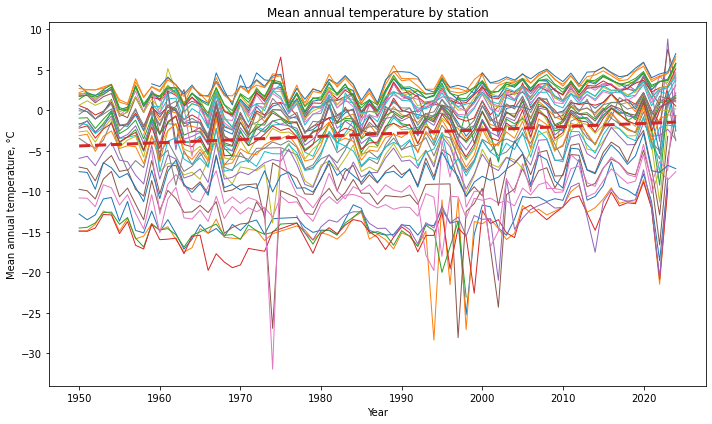

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1. Файл с данными ----------
csv_path = 'temperature_data/temperature_filtered.csv'   # поправьте путь при необходимости

# ---------- 2. Читаем и приводим к виду ----------
df = (
    pd.read_csv(csv_path)
      .assign(year=lambda d: d['year'].astype(int))      # гарантируем int
      .sort_values(['station_id', 'year'])
)

# ---------- 3. Строим график ----------
fig, ax = plt.subplots(figsize=(10, 6))

# каждая станция ‑ своя линия
for station_id, grp in df.groupby('station_id'):
    ax.plot(
        grp['year'],
        grp['mean_year_temp'],
        linewidth=1,
        label=str(station_id)
    )

# ---------- 4. Линия общего тренда ----------
x = df['year']
y = df['mean_year_temp']
k, b = np.polyfit(x, y, 1)                 # k ‑ наклон, b ‑ сдвиг
ax.plot(x, k * x + b, '--', linewidth=3, label='trend')

# ---------- 5. Оформление ----------
ax.set_xlabel('Year')
ax.set_ylabel('Mean annual temperature, °C')
ax.set_title('Mean annual temperature by station')
# ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',fontsize='small', frameon=False)  # выносим легенду за пределы графика
plt.tight_layout()
plt.show()


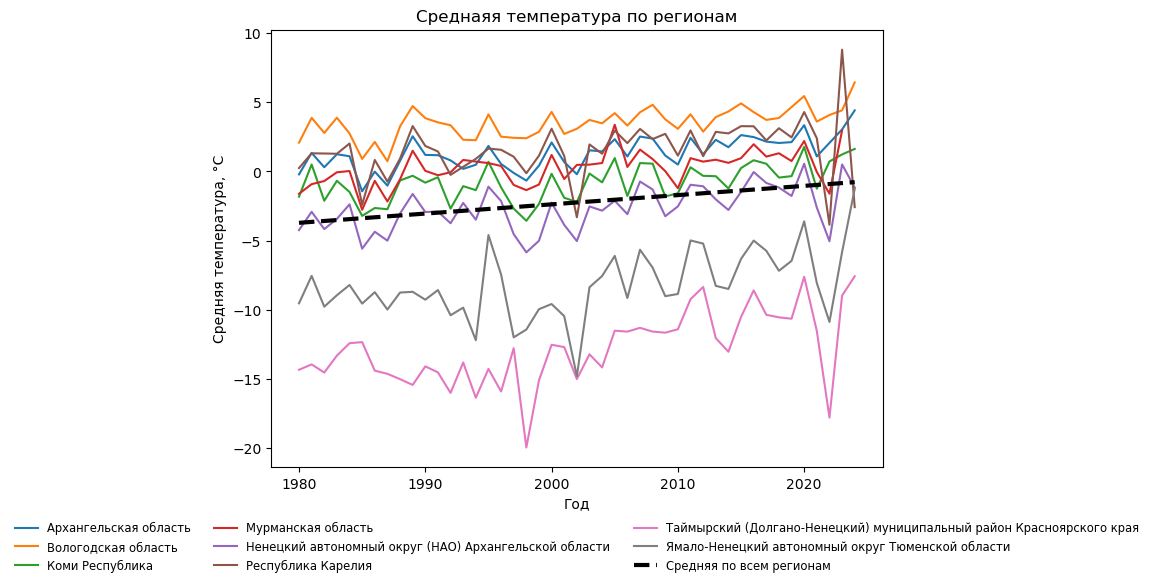

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# 1. Файлы
# ------------------------------------------------------
temp_csv   = 'temperature_data/temperature_filtered.csv'  # годовые T по станциям
xlsx_map   = 'temperature_data/olegy_хелп.xlsx'           # Excel-книга: станция | название | область

# ------------------------------------------------------
# 2. Данные по температуре
# ------------------------------------------------------
df_t = (
    pd.read_csv(temp_csv, dtype={'station_id': str})
      .assign(year=lambda d: d['year'].astype(int))
)

# ------------------------------------------------------
# 3. Карта «станция → область»
# ------------------------------------------------------
map_df = pd.read_excel(
    xlsx_map,
    sheet_name=0,
    usecols=['Индекс', 'Область'],
    dtype=str
)
map_df.columns = ['station_id', 'region']

# ------------------------------------------------------
# 4. Соединяем, убираем Волгоградскую область и оставляем данные с 1980 года
# ------------------------------------------------------
df = (
    df_t.merge(map_df, on='station_id', how='left')
        .dropna(subset=['region'])                         # убираем станции без области
)
df = df[
    (df['region'] != 'Волгоградская область') &
    (df['year'] >= 1980)
]

# ------------------------------------------------------
# 5. Усредняем по областям
# ------------------------------------------------------
by_region = (
    df.groupby(['region', 'year'], as_index=False)
      .agg(region_mean_temp=('mean_year_temp', 'mean'))
)

# ------------------------------------------------------
# 6. График: каждая область — своя линия
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

for region, grp in by_region.groupby('region'):
    ax.plot(
        grp['year'],
        grp['region_mean_temp'],
        linewidth=1.5,
        label=region
    )

# общая линия тренда по всем областям
x = by_region['year']
y = by_region['region_mean_temp']
k, b = np.polyfit(x, y, 1)
ax.plot(
    x,
    k * x + b,
    '--',
    color='black',
    linewidth=3,
    label='Средняя по всем регионам'
)

# ------------------------------------------------------
# 7. Оформление
# ------------------------------------------------------
ax.set_xlabel('Год')
ax.set_ylabel('Средняя температура, °C')
ax.set_title('Среднаяя температура по регионам')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fontsize='small', frameon=False, ncol=3)
plt.tight_layout()
plt.show()




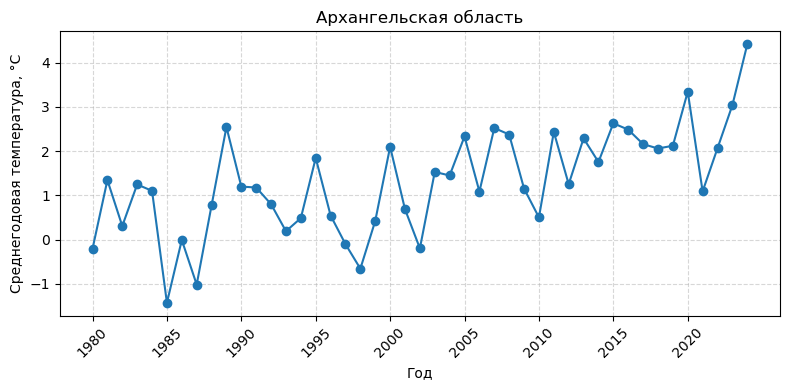

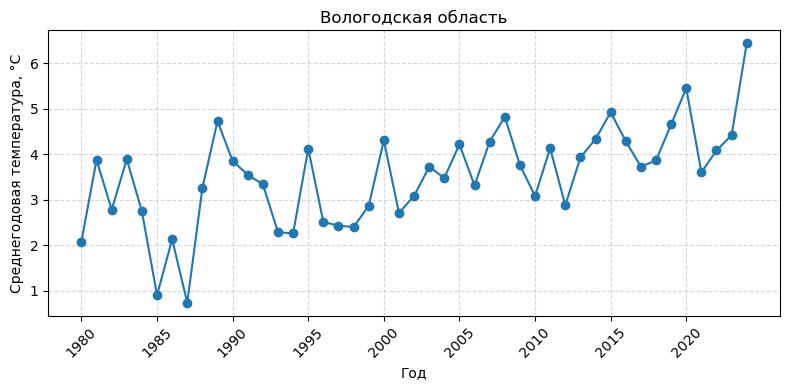

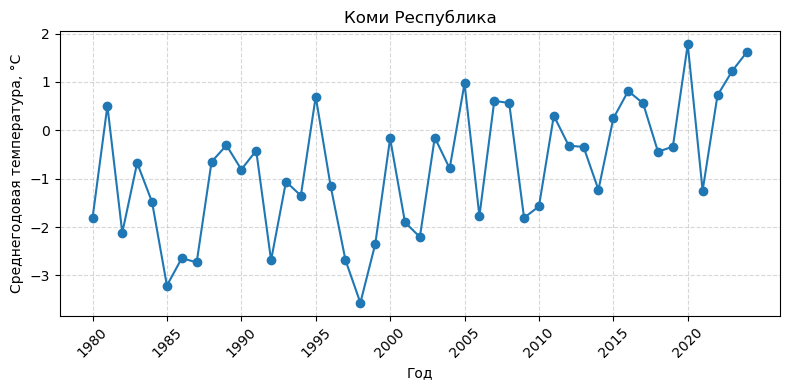

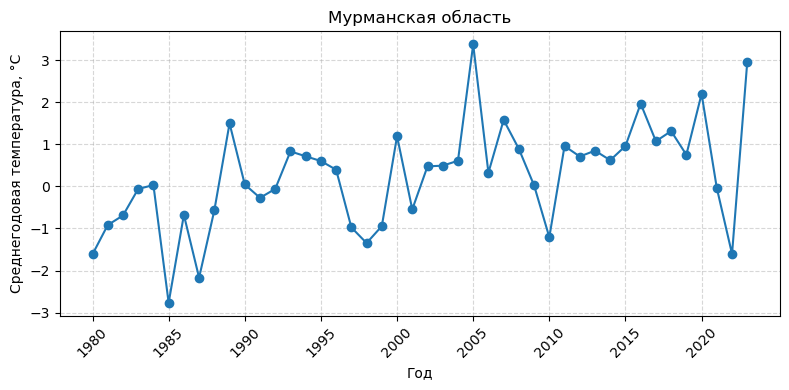

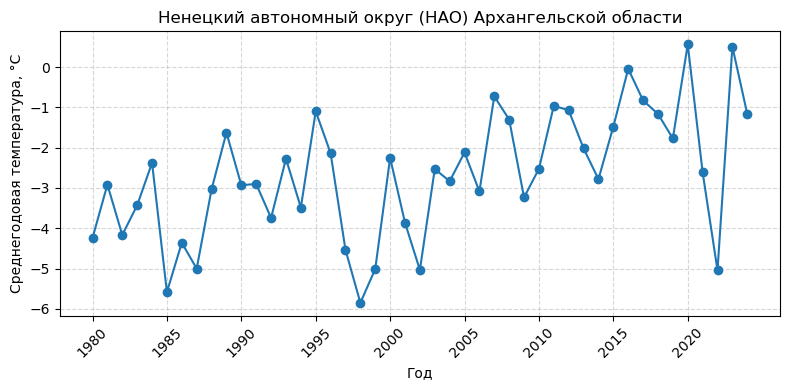

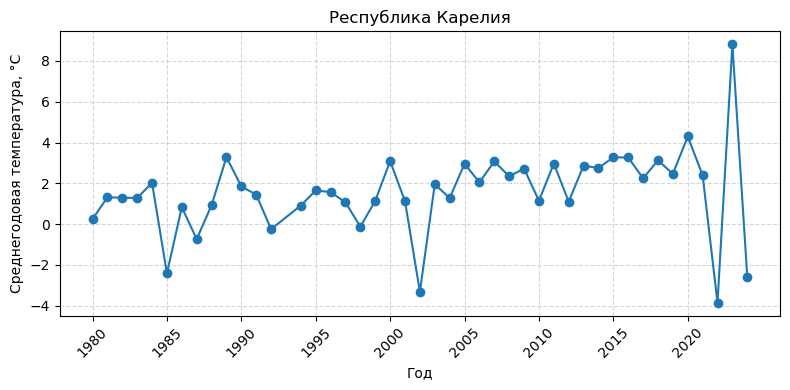

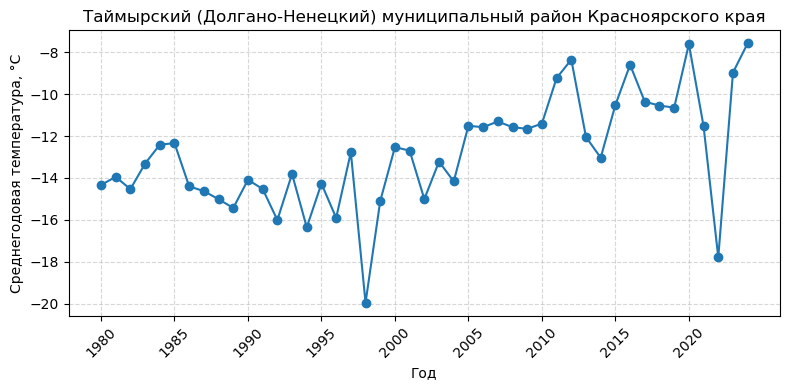

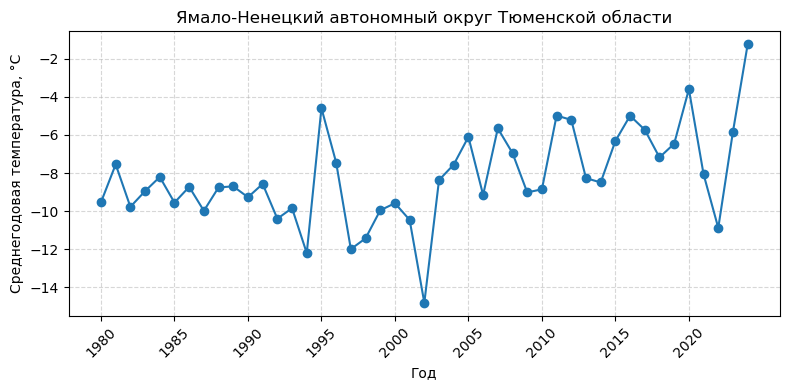

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# 1. Файлы
# ------------------------------------------------------
temp_csv   = 'temperature_data/temperature_filtered.csv'
xlsx_map   = 'temperature_data/olegy_хелп.xlsx'

# ------------------------------------------------------
# 2. Данные по температуре
# ------------------------------------------------------
df_t = (
    pd.read_csv(temp_csv, dtype={'station_id': str})
      .assign(year=lambda d: d['year'].astype(int))
)

# ------------------------------------------------------
# 3. Карта «станция → область»
# ------------------------------------------------------
map_df = pd.read_excel(
    xlsx_map,
    sheet_name=0,
    usecols=['Индекс', 'Область'],
    dtype=str
)
map_df.columns = ['station_id', 'region']

# ------------------------------------------------------
# 4. Соединяем, убираем Волгоградскую область и оставляем данные с 1980 года
# ------------------------------------------------------
df = (
    df_t.merge(map_df, on='station_id', how='left')
        .dropna(subset=['region'])
)
df = df[
    (df['region'] != 'Волгоградская область') &
    (df['year'] >= 1980)
]

# ------------------------------------------------------
# 5. Усредняем по областям
# ------------------------------------------------------
by_region = (
    df.groupby(['region', 'year'], as_index=False)
      .agg(region_mean_temp=('mean_year_temp', 'mean'))
)

# ------------------------------------------------------
# 6. Генерируем отдельный график для каждой области
# ------------------------------------------------------
regions = by_region['region'].unique()

for region in regions:
    grp = by_region[by_region['region'] == region]
    fig, ax = plt.subplots(figsize=(8, 4))
    
    ax.plot(grp['year'], grp['region_mean_temp'], marker='o', linewidth=1.5)
    
    # Оформление
    ax.set_title(f'{region}')
    ax.set_xlabel('Год')
    ax.set_ylabel('Среднегодовая температура, °C')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Только годы, кратные 5
    ticks = [y for y in grp['year'] if y % 5 == 0]
    ax.set_xticks(ticks)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


In [41]:
import pandas as pd

# -------------------------------------------------
# 1. Пути к файлам
# -------------------------------------------------
temp_csv = 'temperature_data/temperature_filtered.csv'   # файл со среднегодовой температурой
xlsx_map = 'temperature_data/olegy_хелп.xlsx'            # 2‑й лист: код станции | населённый пункт

# -------------------------------------------------
# 2. Данные по температуре
# -------------------------------------------------
df_temp = pd.read_csv(temp_csv, dtype={'station_id': str})

# -------------------------------------------------
# 3. «Где расположена станция» — берём из 2‑го листа
#    В нём два столбца: индекс станции и название населённого пункта
# -------------------------------------------------
df_loc = (
    pd.read_excel(xlsx_map, sheet_name=0, header=None, dtype=str, usecols=[0, 2])
      .rename(columns={0: 'station_id', 2: 'location'})
      .assign(station_id=lambda d: d['station_id'].str.strip(),
              location   =lambda d: d['location'].str.strip())
)

# -------------------------------------------------
# 4. Объединяем: добавляем колонку 'location'
# -------------------------------------------------
df_out = (
    df_temp
      .merge(df_loc, on='station_id', how='left')   # left‑join, чтобы сохранить все станции
)

# -------------------------------------------------
# 5. Сохраняем обновлённый файл
# -------------------------------------------------
df_out.to_csv('temperature_data/temperature_with_location.csv', index=False, encoding='utf-8-sig')

print('Готово: добавлена колонка "location" (населённый пункт). Файл:',
      'temperature_with_location.csv')


Готово: добавлена колонка "location" (населённый пункт). Файл: temperature_with_location.csv
